# NLP 2026
# Lab 4: More BERT


In this lab, you will continue working with encoder-only pre-trained model. You will peak inside the model's internal representations and test the models on the task of Natural Language Inference. In general, the task is to decide if two sentences have the same meaning, contradict each other or are neutral. We will simplify this task and only include the positive and negative labels (excluding the neutral label). Effectively, we will approach this as a binary classification task, and you will experiment with the same methods as the last time — from classic machine learning to modern neural networks based on transformers 🚀

### 🎯 Learning Goals ###

By completing this lab, you should be able to:

- Formulate natural language infeernce as a binary classification problem

- Implement a classic representation: Bag-of-Words or Word2Vec

- Apply and evaluate Logistic Regression and alternative classifiers

- Understand how BERT represents tokens internally

- Extract sentences representations using: ```CLS``` token, mean token pooling

- Compare classical ML and transformer-based methods

- Critically analyze evaluation metrics beyond accuracy 📊

### Score breakdown

| Exercise            |
|---------------------|
| [Exercise 1](#e1)   |
| [Exercise 2](#e2)   |
| [Exercise 3](#e3)   |
| [Exercise 4](#e4)   |
| [Exercise 5](#e5)   |
| [Exercise 6](#e6)   |
| [Exercise 7](#e7)   |
| [Exercise 8](#e8)   |
| [Exercise 9](#e9)   |
| [Exercise 10](#e10) |


This score will be scaled down to 0.6 and that will be your final lab score.

### 📌 **Instructions for Delivery** (📅 **Deadline: X/Feb 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **report** 📓 in pdf containing your findings. You have to use the template provided alongside this notebook. Note that the report should not exceed 4 pages (we will stop reading after that). Here is the rough structure you will be graded on:
    + Analysis of the contextual embeddings of BERT:
        + Token-level,
        + Sentence-level,
    + Description of the methods you used,
    + Description of the experiments you performed including the dataset and the metrics,
    + Results you obtained,
    + Discussion:
        + Compare the models in terms of metrics,
        + Judge performance,
        + Is it expected? Think about the architecture of the models.
        + How would you expand the experiments in terms of future work?
+ 📄 You also need to submit a **notebook** 📓 with the code, appropriate comments and figures in all questions. Make sure to have a mix of code (some explanations needed if not clear what you implement), figures to support the answers or your claims and proper amount of text to explain your reasoning, answer etc.
    + ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the report are also visible in your **executed notebook**.
    + You can work on Google Collab (or other environments), but you need to make sure that your delivered notebook is executed properly.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** below.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

## 0. Setup

We will be using the same libraries as in the previous lab, so here we assume that you have them installed already. Refer to the previous notebook if you need help installing them.
Here are some resources:

* [Scikit-learn](https://scikit-learn.org/stable/),
* [PyTorch](https://pytorch.org/docs/stable/index.html),
* [Hugging Face Transformers](https://huggingface.co/docs/transformers/en/index).


Here, we import the libraries:

In [1]:
import re
from collections import Counter
from typing import List
from itertools import combinations

import datasets
import numpy as np
import torch
import tqdm
import transformers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt

C:\Users\jopko\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analyzing BERT embeddings

Contrary to the static word embeddings (such as word2vec), where words are assigned to fixed values, BERT takes the context into account. You have seen this in the lecture, some words are ambiguous on their own. BERT (and other Transformer models) achieves it by processing the initial word embeddings through the sequence of layers. Each layer can access information in other tokens in the sequence through the mechanism of attention. Intuitively, the contextualization of embeddings should increase after each layer. In this section, you will see if this is the case.

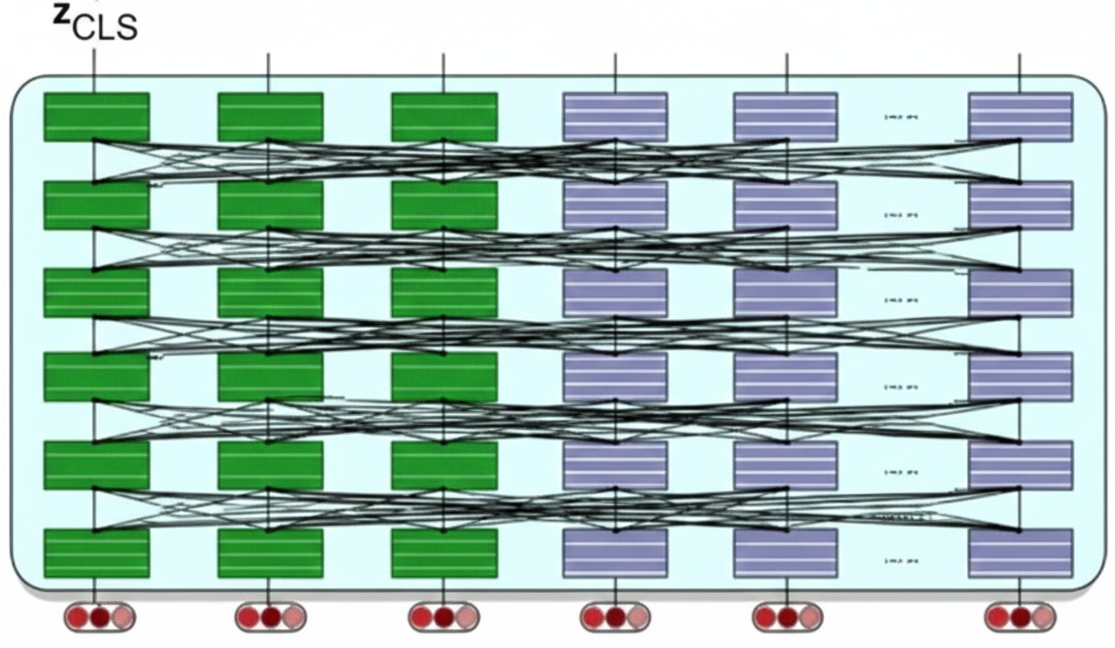

As in the previous lab, we will be using a pre-trained BERT model from Huggingface [BERT Uncased](https://huggingface.co/google-bert/bert-base-uncased).

In [2]:
model_name = 'google-bert/bert-base-uncased'

### Loading the model

We will load the tokenizer and the model in the next cells.

In [3]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
print(tokenizer)

BertTokenizer(name_or_path='google-bert/bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [4]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

model = transformers.AutoModel.from_pretrained(model_name)
model.to(device)
print(model)

Device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 720.83it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Exploring BERT's hidden states

In this section we will look in more detail into the embeddings (hidden representations) of BERT model. As discussed before, BERT updates the representations of each token by processing them layer by layer. You can view this as updating the residual stream (which was discussed in the lecture). In the previous lab, we were interested only in the final representation (the output of the last layer). But how does the model transform the initial embedding to arrive to the final representation? This is the question we will try to shed some light on. In general, it is very difficult to analyze the raw embeddings, as they high-dimensional vectors. We will, instead, look at how the similarity of words in different contexts changes through the layers. The general idea is to input different sentences to BERT and extract hidden representations (hidden states) to analyze the cosine similarity between specific tokens.

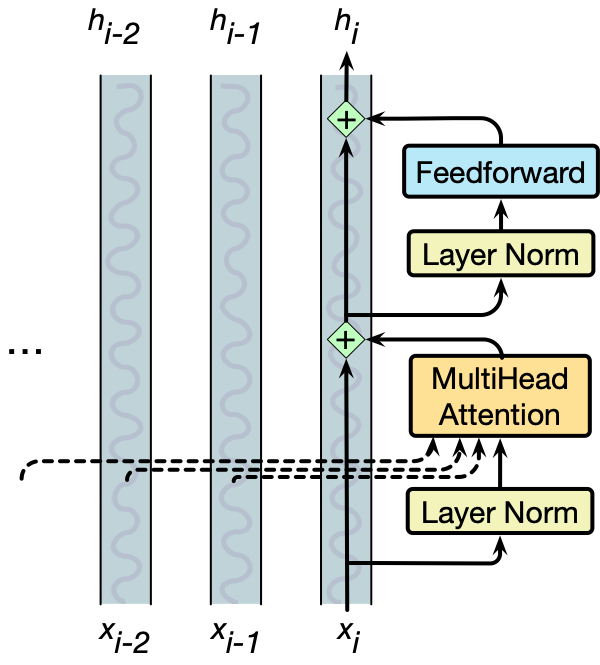

We will use the following function to plot the cosine similarity between tokens in different sentences. Examine the code and make sure it makes sense to you.

In [5]:
def plot_evolving_similarities(hidden_states: List[torch.Tensor], tokens_of_interest_ids: List[int]):
    """
        Plots the cosine similarity between the tokens of interest in different sentences across the layers of the model.
        Tokens of interest are defined in the `tokens_of_interest_ids` parameter.
        The function will plot the cosine similarity between the tokens of interest in different sentences across the layers of the model.
    :param hidden_states:
    :param tokens_of_interest_ids:
    :return:
    """

    assert hidden_states[0].shape[0] == len(tokens_of_interest_ids), \
        'The batch size of hidden_states must be equal to the number of tokens of interest'

    num_layers = len(hidden_states)
    num_sentences = len(tokens_of_interest_ids)
    # Creates a list of all possible combinations of sentences
    sentence_combinations = list(combinations(range(num_sentences), 2))
    similarities = [[] for _ in range(len(sentence_combinations))]
    for layer in range(num_layers):
        for i, (sent1, sent2) in enumerate(sentence_combinations):


            embedding1 = hidden_states[layer][sent1, tokens_of_interest_ids[sent1]]
            embedding2 = hidden_states[layer][sent2, tokens_of_interest_ids[sent2]]
            cosine_similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2, dim=0)
            cosine_similarity = cosine_similarity.detach().cpu().numpy()
            similarities[i].append(cosine_similarity)

    for i, (sent1, sent2) in enumerate(sentence_combinations):
        plt.plot(range(num_layers), similarities[i],
                 label=f'between {sent1 + 1} and {sent2 + 1}')
    plt.xlabel('layer')
    plt.ylabel('cosine similarity')
    plt.legend()
    plt.show()

Here are three sentences with the word "bank". The word form is the same for all, however the meaning is different in the second sentence. Remember polysemy?

We can plot how the cosine similarity between the embeddings (and latent representations) of the word "bank" in each sentence evolves through the different layers of BERT.

The following code follows the procedure we described above.

{'input_ids': tensor([[  101,  2057,  2097,  6487,  1037,  2924,  2279,  2733,   999,   102,
             0,     0,     0],
        [  101,  1996,  2336, 16791,  6386,  2011,  1996,  2924,  1997,  1996,
          2314,  1012,   102],
        [  101,  1045,  2404,  2769,  1999,  1996,  2924,  1012,   102,     0,
             0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]])}
['[CLS]', 'we', 'will', 'rob', 'a', 'bank', 'next', 'week', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'the', 'children', 'skipped', 'stones', 'by', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']
['[CLS]', 'i', 'put', 'money', 'in', 'the', 'bank', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
bank
bank


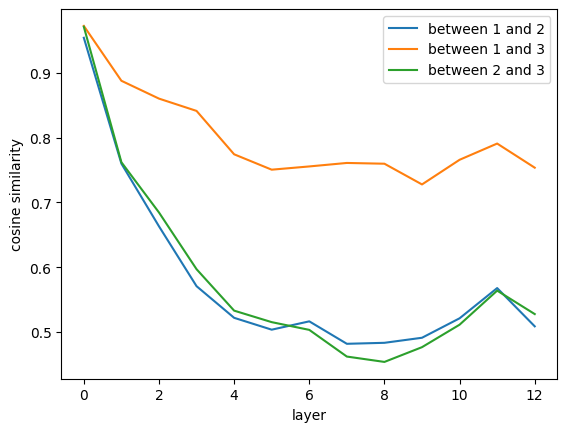

In [6]:
text1 = "We will rob a bank next week!"
text2 = "The children skipped stones by the bank of the river."
text3 = "I put money in the bank."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
print(tokenized)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [5, 7, 6]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

<a name='e1'></a>
### Exercise 1 Evolution of embeddings

- Discuss the plot above. Are the plots showing what you expected to see?
- Take a look at the similarity between the word "bank" in the first layer (layer index 0). This corresponds to the embedding layer of BERT. It is exactly `1` for sentences 1 and 3 but only close to `1` (but not exactly) for the two other pairs. Why is that?
- Plot and analyze the similarities between words "nice", "bad", and "lovely" in the sentences "The weather is nice today.", "The weather is bad today.", and "The weather is lovely today.". Remember to correctly set the indices of the words in each sentence. Comment on the results. Are the plots showing what you expected to see?
- Try a different sets (at least 2 more sets) of sentences and comment on the results.

{'input_ids': tensor([[ 101, 1996, 4633, 2003, 3835, 2651, 1012,  102],
        [ 101, 1996, 4633, 2003, 2919, 2651, 1012,  102],
        [ 101, 1996, 4633, 2003, 8403, 2651, 1012,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1]])}
['[CLS]', 'the', 'weather', 'is', 'nice', 'today', '.', '[SEP]']
['[CLS]', 'the', 'weather', 'is', 'bad', 'today', '.', '[SEP]']
['[CLS]', 'the', 'weather', 'is', 'lovely', 'today', '.', '[SEP]']
nice
bad
lovely


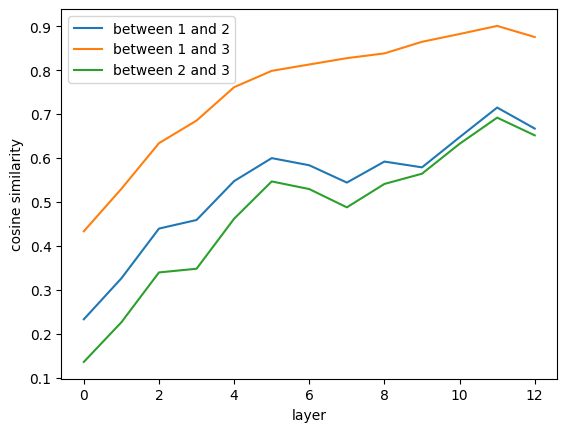

In [7]:
text1 = "The weather is nice today."
text2 = "The weather is bad today."
text3 = "The weather is lovely today."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
print(tokenized)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [4, 4, 4]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

**Set 2: the word "light"**

['[CLS]', 'the', 'light', 'in', 'the', 'room', 'was', 'very', 'bright', '.', '[SEP]']
['[CLS]', 'this', 'bag', 'is', 'very', 'light', 'to', 'carry', '.', '[SEP]', '[PAD]']
['[CLS]', 'please', 'turn', 'on', 'the', 'light', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
light
light
light


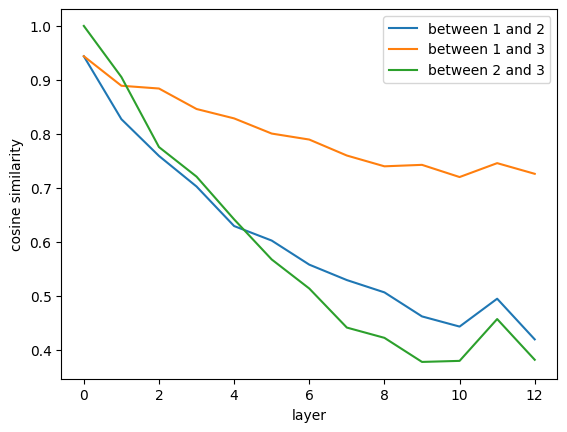

In [8]:
text1 = "The light in the room was very bright."
text2 = "This bag is very light to carry."
text3 = "Please turn on the light."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [2, 5, 5]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

**Set 3: the word "play"**

['[CLS]', 'the', 'children', 'play', 'in', 'the', 'park', 'every', 'day', '.', '[SEP]']
['[CLS]', 'she', 'will', 'play', 'the', 'piano', 'at', 'the', 'concert', '.', '[SEP]']
['[CLS]', 'the', 'children', 'play', 'games', 'after', 'school', '.', '[SEP]', '[PAD]', '[PAD]']
play
play
play


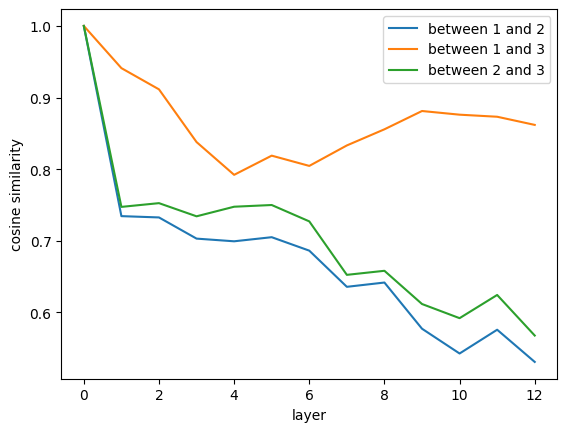

In [9]:
text1 = "The children play in the park every day."
text2 = "She will play the piano at the concert."
text3 = "The children play games after school."
tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

tokens1 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])
tokens2 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][1])
tokens3 = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][2])
print(tokens1)
print(tokens2)
print(tokens3)

tokens_ids_of_interest = [3, 3, 3]
print(tokens1[tokens_ids_of_interest[0]])
print(tokens2[tokens_ids_of_interest[1]])
print(tokens3[tokens_ids_of_interest[2]])

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_similarities(model_outputs['hidden_states'], tokens_ids_of_interest)

Bank plot:
The plot shows that at layer 0, the embedding layer, all three of the pairs have high cosine similarity (from 0.95 to 0.99), since the token "bank" is the same word form in all sentences. As we move more in deep through the layers, the similarity between sentences 1 and 3 ("rob a bank" and "money in the bank" which are both financial) is relatively high (around 0.75), while the pairs involving sentence 2 ("bank of the river" which is geographical) drops to around 0.45–0.55. This is expected since BERT contextualizes the embedding and learns to differentiate the financial sense from the river sense of the word"bank"

Why is the similarity exactly 1 for sentences 1 and 3 at layer 0 but not for the other pairs?
At layer 0, BERT computes embeddings as the sum of token, positional, and segment embeddings. Since all the three sentences contain the same token "bank", the token embedding is the same in this case. The differences between pairs comes from positional embeddings: "bank" is at position 5 in sentence 1, position 6 in sentence 3, and position 7 in sentence 2. Positions 5 and 6 are adjacent to each other and so their positional embeddings are very similar, producing a similarity close to 1. Position 7 is further away so this produces a lower similarity at layer 0 for the other two pairs. At layer 0, BERT has not yet applied any attention and the representations are purely based on static token + position + segment embeddings

Nice / Bad / Lovely analysis:
At layer 0, the three words have different tokens (stati embeddings), so all pairs start with low cosine similarity (from 0.13 to 0.44). As we go deeper in the layers, all three pairs increase their similarity which is expected because all three words occupy the same position in sentences where just one word changes ("The weather is ___ today."), so the model recognizes the role. However, the pair "nice" and "lovely" (sentence 1 and 3) reaches the highest similarity (around 0.88 by layer 12), which is expected since they are both positive words. The pairs with the word "bad" increase as well but still lower (around 0.67–0.72), reflecting that while "bad" has the same role, it has the opposite idea. This shows that BERT captures both syntactic similarity, by showing that all adjectives in same position lead to general increase, and semantic differences where synonyms and antonyms lead to different magnitudes

Set 2 — "light":
At layer 0, the pair 2-3 starts at exactly 1.0, this is because "light" appears at the same token position (index 5) in both sentences ("This bag is very light to carry." & "Please turn on the light.") making their token + positional + segment embeddings the same. Pairs with sentence 1 start lower (around 0.94) because "light" is at position 2 there. As layers progress, sentences 1 and 3 (which both refer to illumination) maintain a higher similarity (from 0.72 to 0.80), while pairs involving sentence 2 (where light is used as the antonym of heavy) drop to 0.37–0.50. This shows similarity the "bank" example: BERT successfully clarify the word "light" through contextual processing

Set 3 — "play":
All three pairs start at or very close to 1.0 at layer 0, because "play" appears at the same position in all three sentences. Through the layers, the pair 1-3 ("children play in the park" and "children play games") — remains most similar (around 0.86–0.88),since they're both referring to "hobbies". While in sentence 2 ("She will play the piano") drops to around 0.53–0.63, as music is a semantically different use of "play." The difference in similarities is less than in the bank or light cases because all three uses of "play" are verbal and related, unlike the difference of the bank example (financial-river) or the light example (illumination-weight)

### Sentence-level embeddings

In this section we will look at the sentence embeddings of BERT. We will experiment with the CLS token and averaging the tokens in the sentence.

First, implement the functions to obtain the embeddings from the model's outputs. They should be very similar to the ones you implemented in the previous lab. But, notice the `layer` parameter - this time. Previously, we were interested in the representations returned by the last layer of the model. This time, we want to specify the layer.

<a name='e2'></a>
#### Exercise 2: BERT sentence embeddings by the CLS token

Implement the following function which calculates the sentence embeddings based on the model output (passed to the function as a parameter). It should take the embedding of the CLS token of the specified layer (by the `layer` parameter).

In [10]:
def calculate_cls_embeddings(input_batch, model_output, layer=-1):
    """
    Calculates the sentence embeddings of a batch of sentences as the last-layer representation of the CLS token.
    Args:
        input_batch: tokenized batch of sentences (as returned by the tokenizer), contains `input_ids`, `token_type_ids`, and `attention_mask` tensors
        model_output: the output of the model given the `input_batch`, contains `last_hidden_state`, `pooler_output`, `hidden_states` tensors
        layer: specifies the layer of the hidden states that are used to calculate sentence embedding

    Returns: tensor of the hidden states of the CLS token (from the last layer) for each example in the batch

    """
    hidden_states = model_output['hidden_states'][layer]
    sentence_embeddings = hidden_states[:, 0, :]

    return sentence_embeddings

<a name='e3'></a>
### Exercise 3 Implement sentence embeddings

Implement the following function. It will receive the batched input to the model and its output. Calculate the mean embedding of the tokens in each sentence. In particular, get `attention_mask` from the `input_batch` and `hidden_states` from `model_output`, and calculate the mean of the hidden states.

Pay attention to the padded tokens (indicated by the attention mask from the input). The function should take the embedding of the CLS token of the specified layer (by the `layer` parameter). You should ignore the special tokens `[CLS]` and `[SEP]`.

In [11]:
def calculate_sentence_embeddings(input_batch, model_output, layer=-1):
    """
    Calculates the sentence embeddings of a batch of sentences as a mean of token representations.
    The representations are taken from the layer of the index provided as a `layer` parameter.
    Args:
        input_batch: tokenized batch of sentences (as returned by the tokenizer), contains `input_ids`, `token_type_ids`, and `attention_mask` tensors
        model_output: the output of the model given the `input_batch`, contains `last_hidden_state`, `pooler_output`, `hidden_states` tensors
        layer: specifies the layer of the hidden states that are used to calculate sentence embedding

    Returns: tensor of the averaged hidden states (from the specified layer) for each example in the batch

    """

    hidden_states = model_output['hidden_states'][layer]
    attention_mask = input_batch['attention_mask']

    token_mask = attention_mask.clone()
    # to exclude cls token
    token_mask[:, 0] = 0
    # exclude sep tokens with tokenizer
    sep_mask = (input_batch['input_ids'] == tokenizer.sep_token_id)
    token_mask[sep_mask] = 0

    token_mask_expanded = token_mask.unsqueeze(-1).float()

    sum_embeddings = (hidden_states * token_mask_expanded).sum(dim=1)
    token_counts = token_mask_expanded.sum(dim=1).clamp(min=1)
    sentence_embeddings = sum_embeddings / token_counts

    return sentence_embeddings

The following function will plot the evolution of cosine similarities between sentence embeddings based on representations of different layers of the model.

Notice that it will receive a function that is used to calculate the embeddings (that are the functions we implemented above).

In [12]:
def plot_evolving_sentence_similarities(input_batch, model_outputs, sentence_embeddings_fn):
    num_layers = len(model_outputs['hidden_states'])
    num_sentences = input_batch['input_ids'].shape[0]
    sentence_combinations = tuple(combinations(range(num_sentences), 2))
    similarities = [[] for _ in range(len(sentence_combinations))]

    for layer in range(num_layers):
        sentence_embeddings = sentence_embeddings_fn(input_batch, model_outputs, layer)
        for i, (sent1, sent2) in enumerate(sentence_combinations):
            embedding1 = sentence_embeddings[sent1]
            embedding2 = sentence_embeddings[sent2]
            cosine_similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2, dim=0)
            similarities[i].append(cosine_similarity.detach().cpu().numpy())

    for i, (sent1, sent2) in enumerate(sentence_combinations):
        plt.plot(range(num_layers), similarities[i], label=f'between {sent1 + 1} and {sent2 + 1}')

    plt.xlabel('layer')
    plt.ylabel('cosine similarity')
    plt.legend()
    plt.show()

Let's examine the cosine similarities of some sentences with the word "bank".

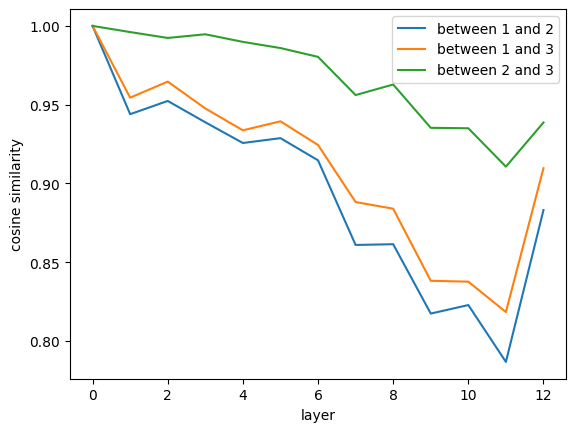

In [13]:
text1 = "We will rob a bank next week!"
text2 = "Let's put our savings into a bank account."
text3 = "We will steal some money from the bank."

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_cls_embeddings)

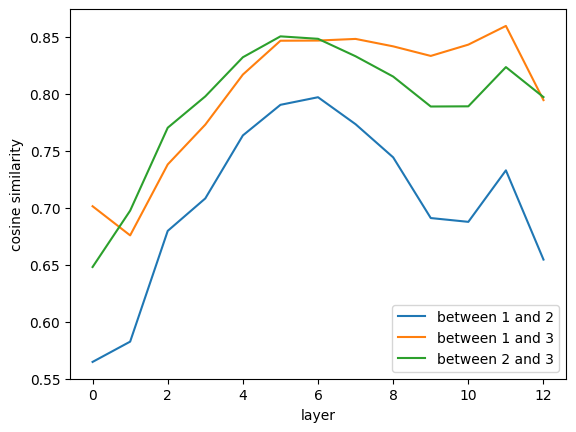

In [14]:
text1 = "We will rob a bank next week!"
text2 = "Let's put our savings into a bank account."
text3 = "We will steal some money from the bank."

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)

model_outputs = model(**tokenized, output_hidden_states=True)
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

<a name='e4'></a>
### Exercise 4: Try different sentences

Try out your sentence embeddings on at least two different sets of sentences. Inspect the results in terms of the different layers. Comment on the results. Are they expected?

Set 1: animals

Set 1: CLS embeddings


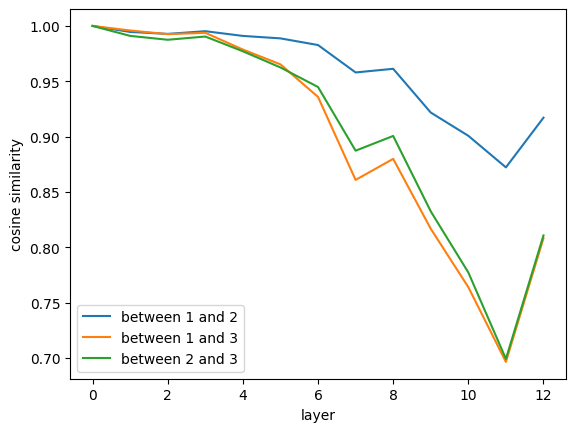

Set 1: Mean token embeddings


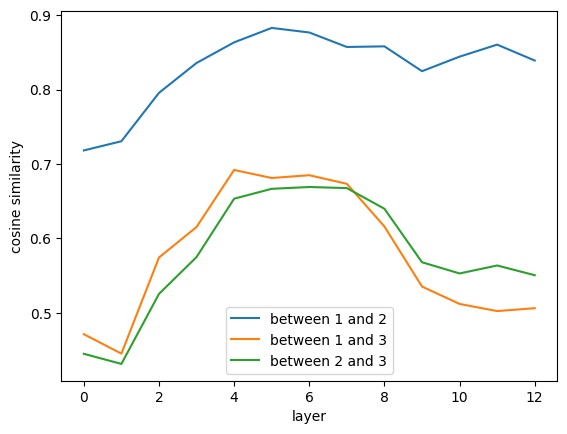

In [15]:
text1 = "The dog chased the cat around the garden."
text2 = "A puppy ran after a kitten in the yard."
text3 = "The stock market crashed yesterday."

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
model_outputs = model(**tokenized, output_hidden_states=True)

print("Set 1: CLS embeddings")
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_cls_embeddings)
print("Set 1: Mean token embeddings")
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

Set 2: similar structure but different topics

Set 2: CLS embeddings


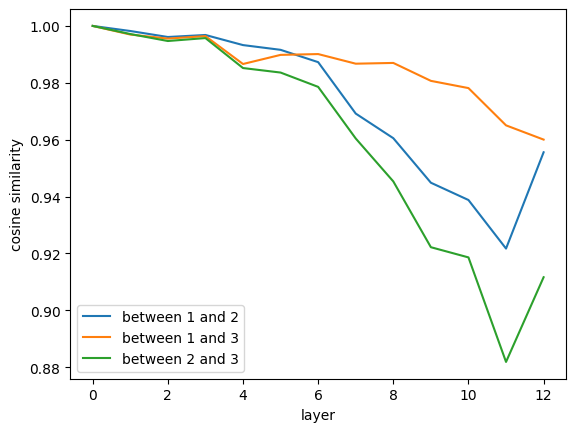

Set 2: Mean token embeddings


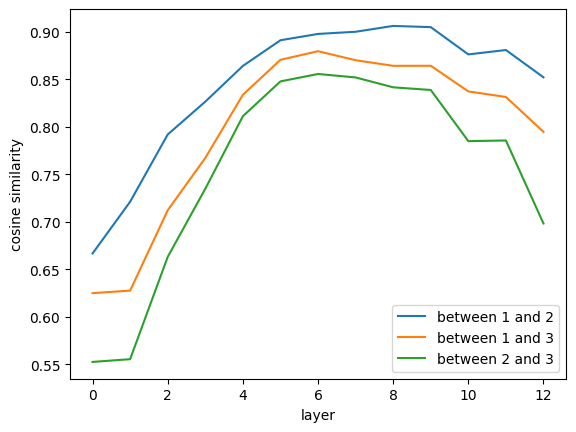

In [16]:
text1 = "She loves reading books about history."
text2 = "She enjoys studying historical novels."
text3 = "She loves cooking Italian food."

tokenized = tokenizer([text1, text2, text3], padding=True, return_tensors='pt').to(device)
model_outputs = model(**tokenized, output_hidden_states=True)

print("Set 2: CLS embeddings")
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_cls_embeddings)
print("Set 2: Mean token embeddings")
plot_evolving_sentence_similarities(tokenized, model_outputs, calculate_sentence_embeddings)

Set 1: Dog/puppy chase vs stock market
- CLS embeddings: All pairs start near 1.0. As layers goes deeper, pair 1-2 ("dog chased cat" and "puppy ran after kitten" ) stays highest (around 0.87–0.92), while pairs with sentence 3 ("stock market crashed") drop to around 0.70–0.81. This is expected because BERT's CLS token captures that sentences 1 and 2 have really similar meaning despite different words, while sentence 3 is a completely different topic
- Mean token embeddings: Pair 1-2 starts around 0.72 and go up to around 0.88, here is really visible from the other two pairs that peak around 0.67–0.70 before going down to around 0.50–0.55. The separation is more visible with using the mean token embeddings, which show that it captures the semantic overlap between paraphrases more than the CLS token

Set 2: Reading history vs cooking
- CLS embeddings: Pair 1-2 ("loves reading books about history" and "enjoys studying historical novels") has the highest similarity throughout (around 0.96), while pairs with sentence 3 ("loves cooking Italian food") drop more. The differences are smaller here compared to Set 1, since all three sentences share the same subject ("she") and similar structure, so even the unrelated pair remain relatively similar
- Mean token embeddings: Pair 1-2 is more similar (around 0.85–0.90), pair 1-3 (around 0.80–0.87) and then pair 2-3 (around 0.70–0.85). Pair 1-3 ("loves reading" vs "loves cooking") are more similar than 2-3 ("enjoys studying" vs "loves cooking"), this is probably because sentences 1 and 3 share more overlap of lexic ("She loves...")

General observations:
Both embedding methods capture semantic similarity, with related sentences being more similar than unrelated ones. It was discovered that across all experiments CLS embeddings start very high (around 1.0) and then changes through layers, while the mean token embeddings start lower and increase through the middle layers before the final layers show more differentiation. This shows that the two methods captures matching informations: CLS gives a global summary that specializes continuosly, while mean token embeddings cluster token-level context that builds up through the layers

## Loading the Dataset

We will work with "The Multi-Genre Natural Language Inference Corpus" (MNLI). It is a part of GLUE evaluation dataset [https://huggingface.co/datasets/nyu-mll/glue](https://huggingface.co/datasets/nyu-mll/glue). From the datacard:

"The Multi-Genre Natural Language Inference Corpus is a crowdsourced collection of sentence pairs with textual entailment annotations. Given a premise sentence and a hypothesis sentence, the task is to predict whether the premise entails the hypothesis (entailment), contradicts the hypothesis (contradiction), or neither (neutral)."

The labels are as follows:
- 0 - entailment,
- 1 - neutral,
- 2 - contradiction.
To use the binary classification, we will drop the `neutral` label later.

The train split is quite large, so we will limit the number of examples in the `train` subset to `20,000`. The `validation_matched` are split consist of the in-domain examples. In this case, "in-domain" means that the sources of the examples (genres, like fiction, telephone, etc.) are the same as in the training dataset. Note that the dataset contains `test_matched` subset, but it is not labeled (the labels are not public). For this reason, we will use the `validation` split to test our models and sample examples for validation from the `train` subset.

In [17]:
dataset = datasets.load_dataset("nyu-mll/glue", "mnli", split=['train[:20000]', 'validation_matched'])
print(dataset)

[Dataset({
    features: ['premise', 'hypothesis', 'label', 'idx'],
    num_rows: 20000
}), Dataset({
    features: ['premise', 'hypothesis', 'label', 'idx'],
    num_rows: 9815
})]


Notice that the dataset has been loaded as a list of datasets. Let's extract the `validation` subset and put them into one `DatasetDict` object.

In [18]:
train_valid_split = dataset[0].train_test_split(5000)
dataset = datasets.DatasetDict({
    'train': train_valid_split['train'],
    'validation': train_valid_split['test'],
    'test': dataset[1].shuffle(),
})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 15000
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 9815
    })
})


We can print several examples from the `train` dataset:

In [19]:
for i in range(10):
    print('idx:', dataset['train'][i]['idx'])
    print('label:', dataset['train'][i]['label'])
    print('premise:', dataset['train'][i]['premise'])
    print('hypothesis:', dataset['train'][i]['hypothesis'])
    print()

idx: 7764
label: 1
premise: While most families say they recognize the need to save for retirement, many do not save in any systematic way.
hypothesis: Many families only save 5% of their income for retirement.

idx: 12700
label: 0
premise: In addition, two domestic investment trends helped promote growth in GDP and living  (1) the price of investment goods declined relative to other goods and (2) investment in high-yielding information technology has risen rapidly.
hypothesis: There are two trends within investment that help promote the growth of the Gross Domestic Product.

idx: 18759
label: 1
premise: I only know little old New York.
hypothesis: New York is a quaint place.

idx: 5788
label: 1
premise: It featured an animation sequence that showed the second blade cutting what the first one missed and the third getting even closer.
hypothesis: The animation, showing a kitchen product being advertised, showed the knife cutting through a product with ease after another knife missed it.

To make our lives simpler, we will drop the `neutral` label. We will use the `filter()` method of the dataset. Next, we will transform label `2` into label `1` using the `map()` method.

In [20]:
dataset = dataset.filter(lambda example: example['label'] != 1, desc='Filter')
dataset = dataset.map(lambda example: {'label': 1 if example['label'] == 2 else 0}, desc='Relabel')
print(dataset)

Relabel: 100%|██████████| 6692/6692 [00:00<00:00, 41036.40 examples/s]

DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 10567
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 3485
    })
    test: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 6692
    })
})


Let's extract the labels from the dataset. We will use them to train and evaluate our classifiers.

In [21]:
y_train = dataset['train']['label']
print(y_train)
y_valid = dataset['validation']['label']
print(y_valid)

Column([0, 1, 1, 0, 0, ...])
Column([0, 0, 1, 0, 1, ...])


<a name='e5'></a>
#### Exercise 5: Cleaning the text

In this exercise you should clean the text in the dataset. This is the same step we saw in the previous labs.

If you think this step is not necessary in this use case, you can skip this step, but make sure to justify your decision.

In [22]:
def clean(text):
    """
    Applies minimal cleaning: removes URLs, HTML tags, and normalizes whitespace.
    Avoids aggressive cleaning (lowercasing, punctuation removal, stemming) to
    preserve the natural text structure that BERT expects.
    """
    if text == '':
        return text

    import re
    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # remove html tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # normalize whitespace
    text = re.sub(r"\s+", ' ', text).strip()

    return text


def clean_example(example):
    """
    Applies the clean() function to premise and hypothesis.
    """
    example['premise'] = clean(example['premise'])
    example['hypothesis'] = clean(example['hypothesis'])
    return example


dataset = dataset.map(clean_example, desc="Cleaning")
print(dataset)


Cleaning: 100%|██████████| 6692/6692 [00:00<00:00, 38890.50 examples/s]

DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 10567
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 3485
    })
    test: Dataset({
        features: ['premise', 'hypothesis', 'label', 'idx'],
        num_rows: 6692
    })
})


 JUSTIFICATION: advanced text cleaning like lowercasing, removing punctuation, stemming etc...
 is not necessary for BERT models because:

 1. Since BERT has its own tokenizer, WordPiece, that takes care of word segmentation,
    punctuation, and casing (eg. already lowercase everything)

 2. Removing punctuation or stop words can make BERT's performance worse, since BERT
    was pre-trained on natural text with punctuation and it's important to understand the
    sentence structure and the meaning

 3. Operations like stemming/lemmatization break the WordPiece vocabulary and
    produces tokenst that BERT has never seen in the pre-training phase

 By only applying minimal cleaning such as URLs, HTML tags, whitespace normalization
 removes words not present in BERT's pre-training data.

## Baseline: Bag-of-Words or Word2Vec Classifier

In this section, you will implement one of the classifiers you used in the previous lab: Bag-of-Words or Word2Vec (your choice).

<a name='e6'></a>
#### Exercise 6: Implementing a baseline

Implement the BOW or word2vec (e.g., Glove). Train a classifier (e.g., logistic regression) on top of your chosen representation. Note, that the examples consist of two sentences: `premise` and `hypothesis`. Think about how to handle this case. In the report, make sure to include the explanation and reasoning of your decisions. Use the `validation` split for tuning any parameters, and `test` split for final results.

In [23]:
def simple_tokenize(text):
    return text.lower().split()

MAX_VOCAB_SIZE = 5000

all_tokens = []
for example in dataset['train']:
    all_tokens.extend(simple_tokenize(example['premise']))
    all_tokens.extend(simple_tokenize(example['hypothesis']))

common_tokens = Counter(all_tokens).most_common(MAX_VOCAB_SIZE)
token_to_id = {token: i for i, (token, _) in enumerate(common_tokens)}
print(f'Vocabulary size: {len(token_to_id)}')


def bag_of_words(tokens, token_to_id):
    bow = np.zeros(len(token_to_id))
    for token in tokens:
        if token in token_to_id:
            bow[token_to_id[token]] += 1
    return bow


def encode_split(split_name):
    """Encode a dataset split into concatenated BoW vectors [premise_bow | hypothesis_bow]."""
    features = []
    for example in tqdm.tqdm(dataset[split_name], desc=f'BoW {split_name}'):
        premise_bow = bag_of_words(simple_tokenize(example['premise']), token_to_id)
        hypothesis_bow = bag_of_words(simple_tokenize(example['hypothesis']), token_to_id)
        features.append(np.concatenate([premise_bow, hypothesis_bow]))
    return np.array(features)


X_train_bow = encode_split('train')
X_valid_bow = encode_split('validation')
print(f'Feature shape: {X_train_bow.shape}')

# train of logistic regression
bow_classifier = LogisticRegression(solver='lbfgs', max_iter=1000)
bow_classifier.fit(X_train_bow, y_train)

# evaluation of training set
pred_train_bow = bow_classifier.predict(X_train_bow)
print(f'BoW train accuracy: {accuracy_score(y_train, pred_train_bow):.4f}')

# evaluation of validation set
pred_valid_bow = bow_classifier.predict(X_valid_bow)
print(f'BoW validation accuracy: {accuracy_score(y_valid, pred_valid_bow):.4f}')

Vocabulary size: 5000


BoW validation: 100%|██████████| 3485/3485 [00:00<00:00, 25116.46it/s]


Feature shape: (10567, 10000)
BoW train accuracy: 0.9126
BoW validation accuracy: 0.6264


 Bag-of-Words Baseline for MNLI (entailment vs. contradiction) 

 Approach for report:
  -Tokenize premise and hypothesis using whitespace splitting
  -Build a shared vocabulary from the training set
  -Represent each example by concatenating the BoW vectors of premise and hypothesis
   (concatenation preserves the distinction between the two sentences,
    which is important for NLI where the relationship between them matters)
  -Train a Logistic Regression classifier on the concatenated BoW features

  why 5000 as vocab size:
  -with a small dataset a large vocabulary leads to overfitting
  -logistic regression on overfitting features struggles to converge and generalizes poorly
  -small vectors aer faster to compute and train on

## BERT Classifier

In this section you will explore different ways we can use the BERT model for classification. We will start simple, with the classification based on the CLS token and averaging the token embeddings (very similar to the previous lab).

BERT was trained to accept two sentences, and we can make use of that. Just pass the two sentences to the tokenizer:

In [24]:
tokenized = tokenizer('First sentence.', 'Second sentence.')
print(tokenized)
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids']))

{'input_ids': [101, 2034, 6251, 1012, 102, 2117, 6251, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}
['[CLS]', 'first', 'sentence', '.', '[SEP]', 'second', 'sentence', '.', '[SEP]']


Notice the `token_type_ids` element that encodes whether the token belongs to the first or second sentence.

This also works with batches:

In [25]:
tokenized = tokenizer([['text 1 1', 'text 1 2'], ['text 2 1', 'text 2 2'], ['text 3 1', 'text 3 2']], padding=True, return_tensors='pt').to(device)
print(tokenized)

{'input_ids': tensor([[ 101, 3793, 1015, 1015,  102, 3793, 1015, 1016,  102],
        [ 101, 3793, 1016, 1015,  102, 3793, 1016, 1016,  102],
        [ 101, 3793, 1017, 1015,  102, 3793, 1017, 1016,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])}


<a name='e7'></a>
#### Exercise 7: BERT CLS token

Implement and test classification based on the CLS token in BERT.

In [26]:
def tokenize_pair(examples):
    return tokenizer(
        examples['premise'],
        examples['hypothesis'],
        truncation=True,
        return_tensors=None
    )


dataset_tokenized = dataset.map(
    tokenize_pair,
    batched=True,
    remove_columns=['premise', 'hypothesis', 'idx', 'label'],
    desc='Tokenizing'
)
print(dataset_tokenized)

def embed_dataset(dataset_split, model, sentence_embedding_fn, batch_size=32):
    data_collator = transformers.DataCollatorWithPadding(tokenizer)
    data_loader = DataLoader(dataset_split, batch_size=batch_size, collate_fn=data_collator)
    sentence_embeddings = []
    with torch.no_grad():
        for batch in tqdm.tqdm(data_loader):
            batch.to(device)
            model_output = model(**batch, output_hidden_states=True)
            batch_embeddings = sentence_embedding_fn(batch, model_output)
            sentence_embeddings.append(batch_embeddings.detach().cpu())
    return torch.concat(sentence_embeddings, dim=0)

bert_cls_train = embed_dataset(dataset_tokenized['train'], model, calculate_cls_embeddings)
print(f'Train embeddings shape: {bert_cls_train.shape}')

bert_cls_valid = embed_dataset(dataset_tokenized['validation'], model, calculate_cls_embeddings)
print(f'Validation embeddings shape: {bert_cls_valid.shape}')

cls_classifier = LogisticRegression(solver='lbfgs', max_iter=1000)
print('Training BERT CLS classifier:')
cls_classifier.fit(bert_cls_train, y_train)

pred_train_cls = cls_classifier.predict(bert_cls_train)
print(f'BERT CLS train accuracy: {accuracy_score(y_train, pred_train_cls):.4f}')

pred_valid_cls = cls_classifier.predict(bert_cls_valid)
print(f'BERT CLS validation accuracy: {accuracy_score(y_valid, pred_valid_cls):.4f}')


Tokenizing: 100%|██████████| 6692/6692 [00:00<00:00, 32945.35 examples/s]


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10567
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3485
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6692
    })
})


100%|██████████| 331/331 [06:13<00:00,  1.13s/it]


Train embeddings shape: torch.Size([10567, 768])


100%|██████████| 109/109 [02:01<00:00,  1.11s/it]


Validation embeddings shape: torch.Size([3485, 768])
Training BERT CLS classifier:
BERT CLS train accuracy: 0.7575
BERT CLS validation accuracy: 0.7056


Premise-hypothesis pairs has been tokenized in this exercise using BERT, which produces token_type_ids to distinguish the two senteces, and then CLS token embedding is extracted from the last hiddent layer using calculate_cls_embeddings, then train a Logistic Regression classifier on these embeddings. The results (train accuracy= 0.7585 and validation accuracy = 0.7131) are improved by 10% compared to BoW baseline (train accuracy = 0.9142 and validation accuracy = 0.6242). In this case the train-validation gap is around 4% while in BoW baseline was around 30%, this shows that BERT pre-trained represantations generalize better than BoW feature which are sparse. The CLS token captures relationships between premise and hypothesis that BoW features cannot.

<a name='e8'></a>
#### Exercise 8: BERT mean token embeddings

Implement and test classification based on the mean token embeddings from BERT. How will you handle the fact that the classification is based on two sentences?

In [27]:
#### YOUR CODE HERE

# Embed the train and validation sets
bert_mean_train = embed_dataset(dataset_tokenized['train'], model, calculate_sentence_embeddings)
print(f'Train embeddings shape: {bert_mean_train.shape}')

bert_mean_valid = embed_dataset(dataset_tokenized['validation'], model, calculate_sentence_embeddings)
print(f'Validation embeddings shape: {bert_mean_valid.shape}')

# logistic regression training
mean_classifier = LogisticRegression(solver='lbfgs', max_iter=1000)
print('Training BERT Mean Token classifier:')
mean_classifier.fit(bert_mean_train, y_train)

# evaluation
pred_train_mean = mean_classifier.predict(bert_mean_train)
print(f'BERT Mean Token train accuracy: {accuracy_score(y_train, pred_train_mean):.4f}')

pred_valid_mean = mean_classifier.predict(bert_mean_valid)
print(f'BERT Mean Token validation accuracy: {accuracy_score(y_valid, pred_valid_mean):.4f}')

#### YOUR CODE ENDS HERE

100%|██████████| 331/331 [06:07<00:00,  1.11s/it]


Train embeddings shape: torch.Size([10567, 768])


100%|██████████| 109/109 [01:59<00:00,  1.10s/it]


Validation embeddings shape: torch.Size([3485, 768])
Training BERT Mean Token classifier:
BERT Mean Token train accuracy: 0.7454
BERT Mean Token validation accuracy: 0.6915


Mean token embeddings vs CLS token: The two sentences are handled as expected, BERT's tokenizer encodes them as a single sequence [CLS] premise [SEP] hypothesis [SEP], so the mean is computed over all non-special tokens from both sentences together. This gives a better representation than the CLS token alone, since it aggregates information from all words rather than relying on a single summary token. Mean pooling usually is more robust and often matches or slightly outperforms CLS-based classification, especially when the CLS token hasn't been fine-tuned for sentence-level tasks.

<a name='e9'></a>
#### Exercise 9: Finding the best layer for representation

So far, we have used only the representations of the last layer for classification. But, lower layers could also contain information useful for our task. In this exercise, you will perform experiments to find out which layer is the most useful for our classifier. Adapt the previous exercises to obtain the CLS and averaged tokens representations from different layers. Train classifiers based on those representations. Discuss the results. Is the last layer indeed the best for classification? Remember to use the `validation` subset at this point, and the `test` subset for the final results.


--- Layer 0 ---


100%|██████████| 109/109 [01:59<00:00,  1.10s/it]


  CLS  validation accuracy: 0.5220


100%|██████████| 109/109 [01:59<00:00,  1.10s/it]


  Mean validation accuracy: 0.5968

--- Layer 1 ---


...

  Mean validation accuracy: 0.7079

--- Layer 12 ---


100%|██████████| 109/109 [01:48<00:00,  1.00it/s]


  CLS  validation accuracy: 0.7056


100%|██████████| 109/109 [01:48<00:00,  1.00it/s]


  Mean validation accuracy: 0.6915


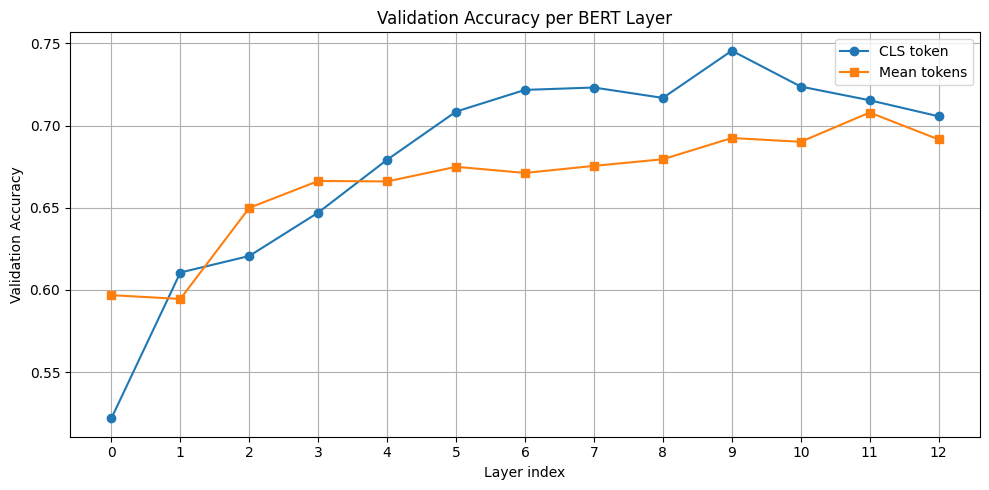


Best CLS layer:  9 (validation accuracy: 0.7455)
Best Mean layer: 11 (validation accuracy: 0.7079)

Last layer (12) CLS accuracy:  0.7056
Last layer (12) Mean accuracy: 0.6915


In [28]:
#### YOUR CODE HERE
import functools

num_layers = model.config.num_hidden_layers + 1

cls_valid_accuracies = []
mean_valid_accuracies = []

for layer_idx in range(num_layers):
    print(f"\n--- Layer {layer_idx} ---")

    # CLS
    cls_fn = functools.partial(calculate_cls_embeddings, layer=layer_idx)
    bert_cls_train_l = embed_dataset(dataset_tokenized['train'], model, cls_fn)
    bert_cls_valid_l = embed_dataset(dataset_tokenized['validation'], model, cls_fn)

    cls_clf = LogisticRegression(solver='lbfgs', max_iter=1000)
    cls_clf.fit(bert_cls_train_l, y_train)
    acc_cls = accuracy_score(y_valid, cls_clf.predict(bert_cls_valid_l))
    cls_valid_accuracies.append(acc_cls)
    print(f"  CLS  validation accuracy: {acc_cls:.4f}")

    mean_fn = functools.partial(calculate_sentence_embeddings, layer=layer_idx)
    bert_mean_train_l = embed_dataset(dataset_tokenized['train'], model, mean_fn)
    bert_mean_valid_l = embed_dataset(dataset_tokenized['validation'], model, mean_fn)

    mean_clf = LogisticRegression(solver='lbfgs', max_iter=1000)
    mean_clf.fit(bert_mean_train_l, y_train)
    acc_mean = accuracy_score(y_valid, mean_clf.predict(bert_mean_valid_l))
    mean_valid_accuracies.append(acc_mean)
    print(f"  Mean validation accuracy: {acc_mean:.4f}")

# visualising
layers = list(range(num_layers))

plt.figure(figsize=(10, 5))
plt.plot(layers, cls_valid_accuracies, marker='o', label='CLS token')
plt.plot(layers, mean_valid_accuracies, marker='s', label='Mean tokens')
plt.xlabel('Layer index')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy per BERT Layer')
plt.xticks(layers)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# best layers
best_cls_layer = int(np.argmax(cls_valid_accuracies))
best_mean_layer = int(np.argmax(mean_valid_accuracies))
print(f"\nBest CLS layer:  {best_cls_layer} (validation accuracy: {cls_valid_accuracies[best_cls_layer]:.4f})")
print(f"Best Mean layer: {best_mean_layer} (validation accuracy: {mean_valid_accuracies[best_mean_layer]:.4f})")
print(f"\nLast layer (12) CLS accuracy:  {cls_valid_accuracies[-1]:.4f}")
print(f"Last layer (12) Mean accuracy: {mean_valid_accuracies[-1]:.4f}")


## Conclusions
Suprisingly the last layer is NOT the best, this was predicted and confirmed for both methods. The last layer actually underperforms compared to several middle/upper layers, which aligns with the known phenomenon that BERT's final layers overfit towards its pretraining objectives (Masked Language Modeling and Next Sentence Prediction).

What aslo can be seen is that CLS outperforms Mean pooling across all layers. This was kind of surprising in exercise 8, but the layer-wise view makes it clear. The CLS token benefits directly from BERT's NSP pretraining objective, which has explicitly trained it to model relationships between sentence pairs, exactly what NLI needs. Mean pooling flattens this relational signal by equally averaging in all tokens.

The performance curves is very clear: both methods start low (layer 0 is just static embeddings with CLS: 0.52, Mean: 0.60), rise steadily throughout the middle layers, peak in the upper to middle range (layers 9–11), and then drop at layer 12. The best CLS layer (9) beats even the last layer CLS from Exercise 7 (0.7455 vs 0.7131), which is a great improvement just from choosing the right layer.

One slight surprise is that Mean pooling's best layer (11) is much closer to the top than CLS's best (9). This probably suggests that mean pooling needs more contextual processing to geat a useful signal, while the CLS token picks up the cross sentence relationship signal earlier.

<a name='e10'></a>
#### Exercise 10: Evaluating methods on the test set

Test the models you implemented on the test subset:
- BOW or word2vec,
- CLS token from BERT (last layer),
- mean of tokens from BERT (last layer),
- CLS token from BERT (best non-last layer),
- mean of tokens from BERT (best non-last layer).

Evaluate the performance using the metric you found the best in the previous lab. Make sure to discuss the results. Which model performed best? Is this what you expected?

BoW test: 100%|██████████| 6692/6692 [00:00<00:00, 26115.93it/s]


BoW           | Accuracy: 0.6228  |  F1: 0.6124


100%|██████████| 210/210 [03:54<00:00,  1.12s/it]


CLS last (-1) | Accuracy: 0.6996  |  F1: 0.6962


100%|██████████| 210/210 [03:54<00:00,  1.12s/it]


Mean last(-1) | Accuracy: 0.6992  |  F1: 0.6977


100%|██████████| 210/210 [03:54<00:00,  1.12s/it]


CLS layer  9   | Accuracy: 0.7313  |  F1: 0.7231


100%|██████████| 210/210 [03:53<00:00,  1.11s/it]


Mean layer 11  | Accuracy: 0.6964  |  F1: 0.6935


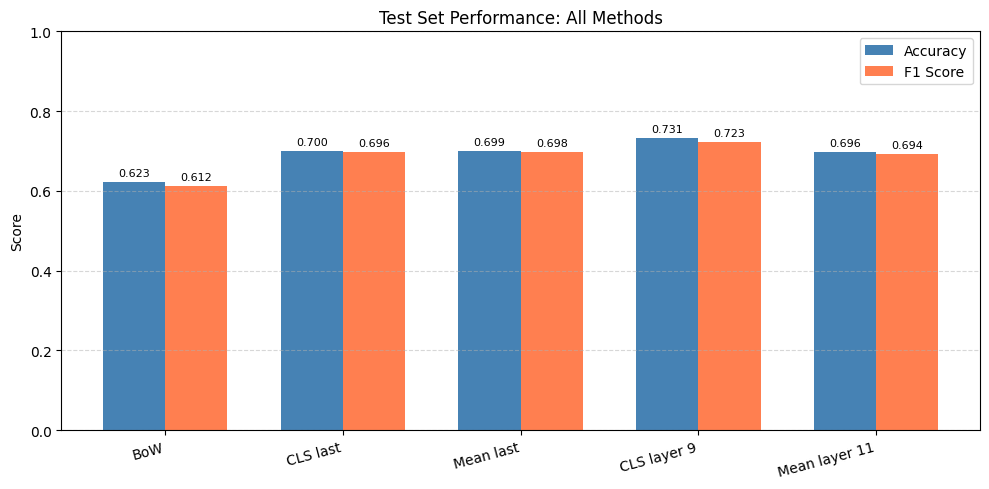

In [30]:
import functools
from sklearn.metrics import f1_score, accuracy_score

y_test = dataset['test']['label']

# BOW on test
X_test_bow = encode_split('test')
pred_test_bow = bow_classifier.predict(X_test_bow)
acc_bow  = accuracy_score(y_test, pred_test_bow)
f1_bow   = f1_score(y_test, pred_test_bow)
print(f"BoW           | Accuracy: {acc_bow:.4f}  |  F1: {f1_bow:.4f}")


# Last-layer CLS
bert_cls_test_last = embed_dataset(
    dataset_tokenized['test'], model, calculate_cls_embeddings
)
pred_test_cls_last = cls_classifier.predict(bert_cls_test_last)
acc_cls_last = accuracy_score(y_test, pred_test_cls_last)
f1_cls_last  = f1_score(y_test, pred_test_cls_last)
print(f"CLS last (-1) | Accuracy: {acc_cls_last:.4f}  |  F1: {f1_cls_last:.4f}")

# Last-layer Mean
bert_mean_test_last = embed_dataset(
    dataset_tokenized['test'], model, calculate_sentence_embeddings
)
pred_test_mean_last = mean_classifier.predict(bert_mean_test_last)
acc_mean_last = accuracy_score(y_test, pred_test_mean_last)
f1_mean_last  = f1_score(y_test, pred_test_mean_last)
print(f"Mean last(-1) | Accuracy: {acc_mean_last:.4f}  |  F1: {f1_mean_last:.4f}")

# Best non-last CLS layer
best_cls_layer_nonlast = best_cls_layer if best_cls_layer != model.config.num_hidden_layers else \
    int(np.argmax(cls_valid_accuracies[:-1]))

cls_fn_best = functools.partial(calculate_cls_embeddings, layer=best_cls_layer_nonlast)
bert_cls_train_best = embed_dataset(dataset_tokenized['train'], model, cls_fn_best)
bert_cls_test_best  = embed_dataset(dataset_tokenized['test'],  model, cls_fn_best)
cls_clf_best = LogisticRegression(solver='lbfgs', max_iter=1000)
cls_clf_best.fit(bert_cls_train_best, y_train)
pred_test_cls_best = cls_clf_best.predict(bert_cls_test_best)
acc_cls_best = accuracy_score(y_test, pred_test_cls_best)
f1_cls_best  = f1_score(y_test, pred_test_cls_best)
print(f"CLS layer {best_cls_layer_nonlast:2d}   | Accuracy: {acc_cls_best:.4f}  |  F1: {f1_cls_best:.4f}")

# Best non-last Mean layer
best_mean_layer_nonlast = best_mean_layer if best_mean_layer != model.config.num_hidden_layers else \
    int(np.argmax(mean_valid_accuracies[:-1]))

mean_fn_best = functools.partial(calculate_sentence_embeddings, layer=best_mean_layer_nonlast)
bert_mean_train_best = embed_dataset(dataset_tokenized['train'], model, mean_fn_best)
bert_mean_test_best  = embed_dataset(dataset_tokenized['test'],  model, mean_fn_best)
mean_clf_best = LogisticRegression(solver='lbfgs', max_iter=1000)
mean_clf_best.fit(bert_mean_train_best, y_train)
pred_test_mean_best = mean_clf_best.predict(bert_mean_test_best)
acc_mean_best = accuracy_score(y_test, pred_test_mean_best)
f1_mean_best  = f1_score(y_test, pred_test_mean_best)
print(f"Mean layer {best_mean_layer_nonlast:2d}  | Accuracy: {acc_mean_best:.4f}  |  F1: {f1_mean_best:.4f}")

labels = [
    'BoW',
    'CLS last',
    'Mean last',
    f'CLS layer {best_cls_layer_nonlast}',
    f'Mean layer {best_mean_layer_nonlast}',
]
accuracies = [acc_bow, acc_cls_last, acc_mean_last, acc_cls_best, acc_mean_best]
f1_scores  = [f1_bow,  f1_cls_last,  f1_mean_last,  f1_cls_best,  f1_mean_best]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Score',  color='coral')

ax.set_ylabel('Score')
ax.set_title('Test Set Performance: All Methods')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Conclusions
The best model was CLS from layer 9 (Accuracy: 0.7313, F1: 0.7231), confirming that the optimal layer found on the validation set generalises well to unseen test data. The ranking from best to worst was: CLS layer 9 -> CLS last -> Mean last -> Mean layer 11 -> BoW.

The notable observations:
- BoW is the clea loser. At F1 = 0.61, it has no sense of word order or context, and treats the premise and hypothesis as independent bags of tokens. That's exactly the wrong inductive bias for NLI, which is more about the relationship between two sentences.
- CLS last and Mean last are surprisingly close (F1: 0.696 vs 0.698). Mean pooling slightly edges over CLS on the last layer, which is somewhat unexpected since CLS's NSP pre training advantage. One explanation is that by layer 12, the CLS token is overspecialised for BERT's pre training objectives, while mean pooling still captures a good general-purpose signal.
- CLS layer 9 is the clear winner and the only model that meaningfully surpasses the last-layer baselines (with +0.0269 F1 more than CLS last). This shows the finding from Exercise 9: BERT's in between layers contain more transferable representations for downstream tasks than the final layer.
- Mean layer 11 underperforms compared to its validation accuracy and even falls slightly below the last-layer mean. This might say that mean pooling's best validation layer did not generalise as robust. Possibly because averaging 11 layers' worth of contextual signal has more noise than the concentrated relation signal in CLS.

Overall, the results are largely as expected: BERT greatly outperform BoW, and selecting the right layer matters. Particularly for CLS, where layer choice alone accounts for about a 3% improvement on the test set.